In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Upload data.csv in Google Colab
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("/content/data.csv")
df



,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [3]:
# Remove unnecessary columns
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")

# Convert diagnosis:
# M = 1 (Malignant)
# B = 0 (Benign)
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Separate features and target
X = df.drop(columns=["diagnosis"]).values
y = df["diagnosis"].values

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

Number of samples: 569
Number of features: 30


In [4]:
np.random.seed(42)

indices = np.arange(len(X))
np.random.shuffle(indices)

X = X[indices]
y = y[indices]

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 455
Testing samples: 114


In [5]:
# Standardize using training data only

mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

std[std == 0] = 1

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print("Standardization completed.")

Standardization completed.


In [6]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))


def manhattan_distance(x1, x2):
    return np.sum(np.abs(x1 - x2))


def minkowski_distance(x1, x2, p=3):
    return np.sum(np.abs(x1 - x2) ** p) ** (1 / p)


def cosine_distance(x1, x2):
    denominator = np.linalg.norm(x1) * np.linalg.norm(x2)

    if denominator == 0:
        return 1

    cosine_similarity = np.dot(x1, x2) / denominator

    return 1 - cosine_similarity


def hamming_distance(x1, x2):
    return np.mean(x1 != x2)

In [7]:
def knn_predict(X_train, y_train, X_test, k, distance_type):

    predictions = []

    for test_point in X_test:

        distances = []

        for i in range(len(X_train)):

            if distance_type == "Euclidean":
                distance = euclidean_distance(
                    test_point, X_train[i]
                )

            elif distance_type == "Manhattan":
                distance = manhattan_distance(
                    test_point, X_train[i]
                )

            elif distance_type == "Minkowski":
                distance = minkowski_distance(
                    test_point, X_train[i]
                )

            elif distance_type == "Cosine":
                distance = cosine_distance(
                    test_point, X_train[i]
                )

            elif distance_type == "Hamming":
                distance = hamming_distance(
                    test_point, X_train[i]
                )

            distances.append(distance)

        distances = np.array(distances)

        # Get indices of k nearest neighbours
        nearest_indices = np.argsort(distances)[:k]

        # Get their labels
        nearest_labels = y_train[nearest_indices]

        # Majority voting
        values, counts = np.unique(
            nearest_labels,
            return_counts=True
        )

        prediction = values[np.argmax(counts)]

        predictions.append(prediction)

    return np.array(predictions)

In [8]:
def accuracy(y_true, y_pred):

    correct = np.sum(y_true == y_pred)

    return correct / len(y_true)

In [9]:
k_values = [3, 4, 9, 20, 47]

distance_types = [
    "Euclidean",
    "Manhattan",
    "Minkowski",
    "Cosine",
    "Hamming"
]

results = []

for distance in distance_types:

    for k in k_values:

        print(
            "Running:",
            distance,
            "K =", k
        )

        y_pred = knn_predict(
            X_train,
            y_train,
            X_test,
            k,
            distance
        )

        acc = accuracy(y_test, y_pred)

        results.append([
            distance,
            k,
            acc
        ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Distance",
        "K",
        "Accuracy"
    ]
)

results_df

Running: Euclidean K = 3
Running: Euclidean K = 4
Running: Euclidean K = 9
Running: Euclidean K = 20
Running: Euclidean K = 47
Running: Manhattan K = 3
Running: Manhattan K = 4
Running: Manhattan K = 9
Running: Manhattan K = 20
Running: Manhattan K = 47
Running: Minkowski K = 3
Running: Minkowski K = 4
Running: Minkowski K = 9
Running: Minkowski K = 20
Running: Minkowski K = 47
Running: Cosine K = 3
Running: Cosine K = 4
Running: Cosine K = 9
Running: Cosine K = 20
Running: Cosine K = 47
Running: Hamming K = 3
Running: Hamming K = 4
Running: Hamming K = 9
Running: Hamming K = 20
Running: Hamming K = 47


,Distance,K,Accuracy
0,Euclidean,3,0.947368
1,Euclidean,4,0.929825
2,Euclidean,9,0.929825
3,Euclidean,20,0.938596
4,Euclidean,47,0.938596
5,Manhattan,3,0.964912
6,Manhattan,4,0.938596
7,Manhattan,9,0.947368
8,Manhattan,20,0.938596
9,Manhattan,47,0.938596


In [10]:
best_result = results_df.loc[
    results_df["Accuracy"].idxmax()
]

print("Best Distance:", best_result["Distance"])
print("Best K:", int(best_result["K"]))
print("Best Accuracy:", best_result["Accuracy"])

Best Distance: Manhattan
Best K: 3
Best Accuracy: 0.9649122807017544


In [11]:
best_distance = best_result["Distance"]
best_k = int(best_result["K"])

best_prediction = knn_predict(
    X_train,
    y_train,
    X_test,
    best_k,
    best_distance
)

# Confusion matrix from scratch

def confusion_matrix_manual(y_true, y_pred):

    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    return np.array([
        [TN, FP],
        [FN, TP]
    ])


cm = confusion_matrix_manual(
    y_test,
    best_prediction
)

TN, FP = cm[0]
FN, TP = cm[1]

precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("Confusion Matrix:")
print(cm)

print("\nPrecision:", precision)
print("Recall:", recall)
print("Accuracy:", accuracy(y_test, best_prediction))

Confusion Matrix:
[[67  0]
 [ 4 43]]

Precision: 1.0
Recall: 0.9148936170212766
Accuracy: 0.9649122807017544


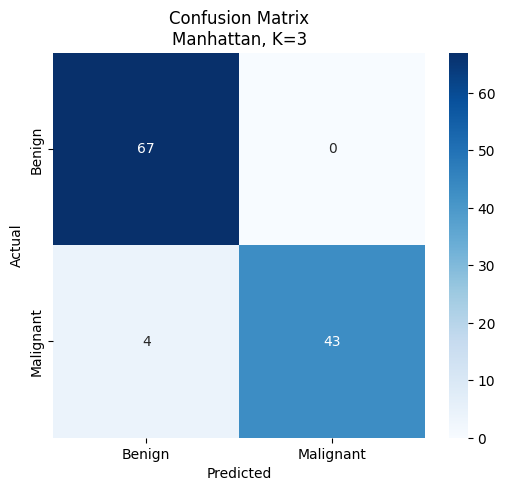

In [12]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    f"Confusion Matrix\n"
    f"{best_distance}, K={best_k}"
)

plt.show()

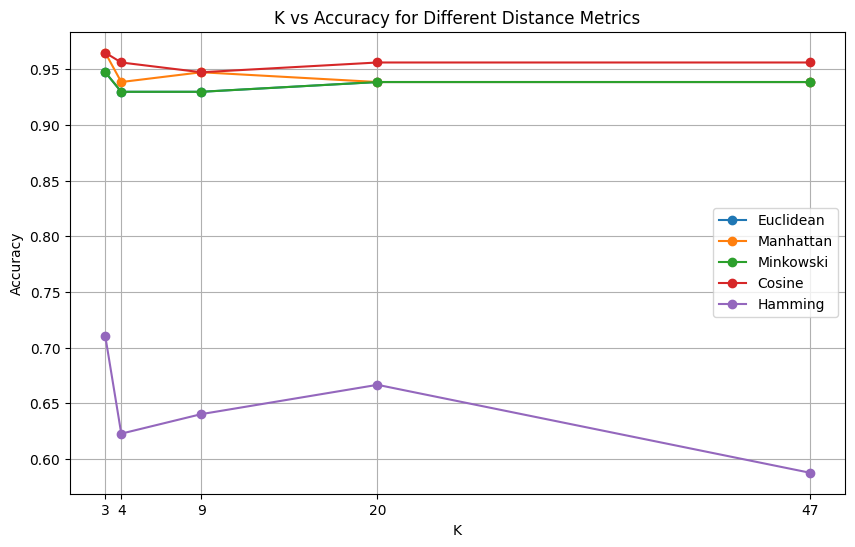

In [13]:
plt.figure(figsize=(10, 6))

for distance in distance_types:

    data = results_df[
        results_df["Distance"] == distance
    ]

    plt.plot(
        data["K"],
        data["Accuracy"],
        marker="o",
        label=distance
    )

plt.xlabel("K")
plt.ylabel("Accuracy")

plt.title(
    "K vs Accuracy for Different Distance Metrics"
)

plt.xticks(k_values)

plt.grid(True)
plt.legend()

plt.show()

In [14]:
print("\n========== FINAL RESULTS ==========\n")

print(results_df.to_string(index=False))

print("\n========== BEST MODEL ==========\n")

print("Distance:", best_distance)
print("K:", best_k)
print("Accuracy:", accuracy(y_test, best_prediction))
print("Precision:", precision)
print("Recall:", recall)

print("\nConfusion Matrix:")
print(cm)


========== FINAL RESULTS ==========

 Distance  K  Accuracy
Euclidean  3  0.947368
Euclidean  4  0.929825
Euclidean  9  0.929825
Euclidean 20  0.938596
Euclidean 47  0.938596
Manhattan  3  0.964912
Manhattan  4  0.938596
Manhattan  9  0.947368
Manhattan 20  0.938596
Manhattan 47  0.938596
Minkowski  3  0.947368
Minkowski  4  0.929825
Minkowski  9  0.929825
Minkowski 20  0.938596
Minkowski 47  0.938596
   Cosine  3  0.964912
   Cosine  4  0.956140
   Cosine  9  0.947368
   Cosine 20  0.956140
   Cosine 47  0.956140
  Hamming  3  0.710526
  Hamming  4  0.622807
  Hamming  9  0.640351
  Hamming 20  0.666667
  Hamming 47  0.587719

========== BEST MODEL ==========

Distance: Manhattan
K: 3
Accuracy: 0.9649122807017544
Precision: 1.0
Recall: 0.9148936170212766

Confusion Matrix:
[[67  0]
 [ 4 43]]


BONUS - KNN DECISION BOUNDARY
Boundary training data: (1000, 3072)
Boundary testing data: (300, 3072)

Running PCA...
2D training data: (1000, 2)
2D testing data: (300, 2)

Grid points: 62500
Calculating decision boundary using K = 47...


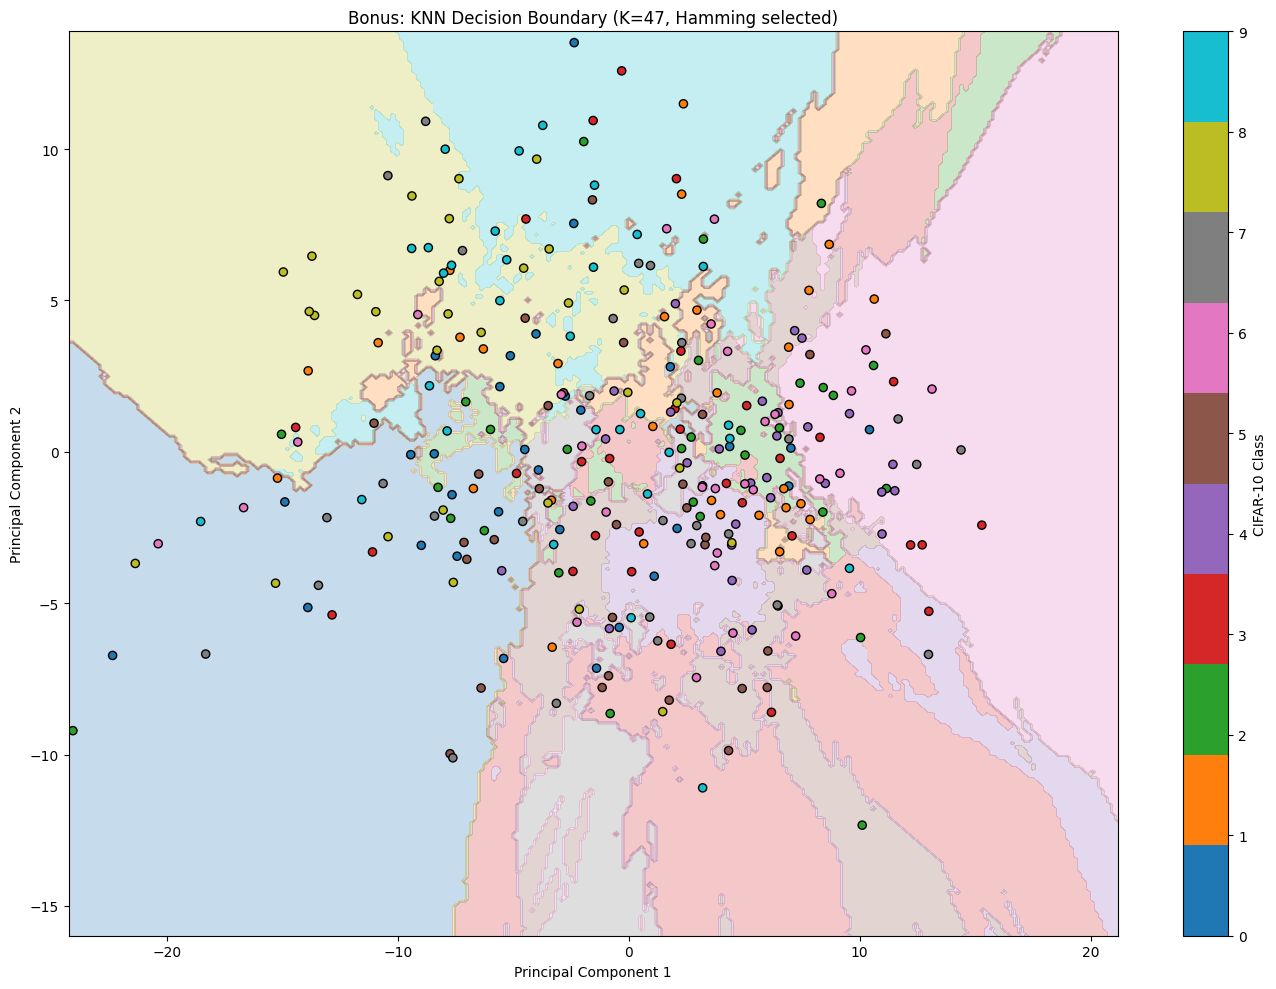

In [28]:
# ============================================================
# CELL 22 - BONUS
# DECISION BOUNDARY VISUALIZATION
# ============================================================

print("=" * 70)
print("BONUS - KNN DECISION BOUNDARY")
print("=" * 70)

# ------------------------------------------------------------
# STEP 1: CREATE A SMALLER DATASET FOR VISUALIZATION
# ------------------------------------------------------------

# Use a smaller balanced subset so the visualization
# remains practical in Google Colab.

BOUNDARY_TRAIN_PER_CLASS = 100
BOUNDARY_TEST_PER_CLASS = 30

boundary_train_indices = []
boundary_test_indices = []

rng = np.random.default_rng(42)

for class_id in range(10):

    train_class_indices = np.where(
        y_train_small == class_id
    )[0]

    test_class_indices = np.where(
        y_test_small == class_id
    )[0]

    rng.shuffle(train_class_indices)
    rng.shuffle(test_class_indices)

    boundary_train_indices.extend(
        train_class_indices[
            :BOUNDARY_TRAIN_PER_CLASS
        ]
    )

    boundary_test_indices.extend(
        test_class_indices[
            :BOUNDARY_TEST_PER_CLASS
        ]
    )

boundary_train_indices = np.asarray(
    boundary_train_indices
)

boundary_test_indices = np.asarray(
    boundary_test_indices
)

X_boundary_train = X_train_small[
    boundary_train_indices
]

y_boundary_train = y_train_small[
    boundary_train_indices
]

X_boundary_test = X_test_small[
    boundary_test_indices
]

y_boundary_test = y_test_small[
    boundary_test_indices
]

print(
    "Boundary training data:",
    X_boundary_train.shape
)

print(
    "Boundary testing data:",
    X_boundary_test.shape
)

# ------------------------------------------------------------
# STEP 2: PCA FROM SCRATCH
# ------------------------------------------------------------

print("\nRunning PCA...")

mean_vector = np.mean(
    X_boundary_train,
    axis=0
)

X_centered = (
    X_boundary_train
    - mean_vector
)

# Singular Value Decomposition
U, S, Vt = np.linalg.svd(
    X_centered,
    full_matrices=False
)

# First two principal components
components = Vt[:2]

X_boundary_train_2D = (
    X_centered @ components.T
)

X_boundary_test_2D = (
    (
        X_boundary_test
        - mean_vector
    )
    @ components.T
)

print(
    "2D training data:",
    X_boundary_train_2D.shape
)

print(
    "2D testing data:",
    X_boundary_test_2D.shape
)

# ------------------------------------------------------------
# STEP 3: KNN FOR 2D DATA
# ------------------------------------------------------------

def knn_2d_predict(
    X_train,
    y_train,
    X_test,
    k
):

    predictions = []

    for point in X_test:

        distances = np.sqrt(
            np.sum(
                (
                    X_train
                    - point
                ) ** 2,
                axis=1
            )
        )

        nearest = np.argpartition(
            distances,
            k - 1
        )[:k]

        labels = y_train[
            nearest
        ]

        counts = np.bincount(
            labels,
            minlength=10
        )

        predictions.append(
            np.argmax(counts)
        )

    return np.asarray(
        predictions
    )

# ------------------------------------------------------------
# STEP 4: CREATE GRID
# ------------------------------------------------------------

x_min = X_boundary_train_2D[:, 0].min() - 1
x_max = X_boundary_train_2D[:, 0].max() + 1

y_min = X_boundary_train_2D[:, 1].min() - 1
y_max = X_boundary_train_2D[:, 1].max() + 1

grid_points = 250

xx, yy = np.meshgrid(
    np.linspace(
        x_min,
        x_max,
        grid_points
    ),
    np.linspace(
        y_min,
        y_max,
        grid_points
    )
)

grid = np.c_[
    xx.ravel(),
    yy.ravel()
]

print(
    "\nGrid points:",
    len(grid)
)

# ------------------------------------------------------------
# STEP 5: PREDICT GRID
# ------------------------------------------------------------

print(
    f"Calculating decision boundary "
    f"using K = {best_k}..."
)

grid_predictions = knn_2d_predict(
    X_boundary_train_2D,
    y_boundary_train,
    grid,
    best_k
)

grid_predictions = grid_predictions.reshape(
    xx.shape
)

# ------------------------------------------------------------
# STEP 6: PLOT DECISION BOUNDARY
# ------------------------------------------------------------

plt.figure(
    figsize=(14, 10)
)

plt.contourf(
    xx,
    yy,
    grid_predictions,
    alpha=0.25,
    levels=np.arange(11) - 0.5,
    cmap="tab10"
)

scatter = plt.scatter(
    X_boundary_test_2D[:, 0],
    X_boundary_test_2D[:, 1],
    c=y_boundary_test,
    cmap="tab10",
    edgecolors="black",
    s=35
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    f"Bonus: KNN Decision Boundary "
    f"(K={best_k}, {best_distance} selected)"
)

plt.colorbar(
    scatter,
    ticks=range(10),
    label="CIFAR-10 Class"
)

plt.tight_layout()

plt.show()

In [29]:
# ============================================================
# CELL 23 - BONUS MODEL ACCURACY IN 2D
# ============================================================

boundary_predictions = knn_2d_predict(
    X_boundary_train_2D,
    y_boundary_train,
    X_boundary_test_2D,
    best_k
)

boundary_accuracy = np.mean(
    boundary_predictions ==
    y_boundary_test
)

print("=" * 70)
print("BONUS RESULTS")
print("=" * 70)

print(
    f"K = {best_k}"
)

print(
    f"Distance used for main model: {best_distance}"
)

print(
    f"2D KNN accuracy: "
    f"{boundary_accuracy:.4f}"
)

print(
    "\nNote:"
)

print(
    "The decision boundary is visualized after reducing "
    "the original 3072-dimensional CIFAR-10 images to "
    "two principal components for visualization."
)

BONUS RESULTS
K = 47
Distance used for main model: Hamming
2D KNN accuracy: 0.1667

Note:
The decision boundary is visualized after reducing the original 3072-dimensional CIFAR-10 images to two principal components for visualization.


TASK-**2**

In [1]:
# ============================================================
# TASK 2 - CIFAR-10 KNN CLASSIFICATION
# OPTIMIZED KNN FROM SCRATCH
# ============================================================

import os
import zipfile
import time
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

np.random.seed(42)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# ============================================================
# DATASET ALREADY EXTRACTED
# ============================================================

import os

extract_path = "/content/cifar10"

TRAIN_PATH = "/content/cifar10/cifar10/train"
TEST_PATH = "/content/cifar10/cifar10/test"

print("Train path:", TRAIN_PATH)
print("Test path :", TEST_PATH)

if os.path.exists(TRAIN_PATH):
    print("✅ Train folder found")
else:
    print("❌ Train folder not found")

if os.path.exists(TEST_PATH):
    print("✅ Test folder found")
else:
    print("❌ Test folder not found")

Train path: /content/cifar10/cifar10/train
Test path : /content/cifar10/cifar10/test
✅ Train folder found
✅ Test folder found


In [5]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

label_map = {
    name: i
    for i, name in enumerate(class_names)
}

print(label_map)

{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


In [7]:
# ============================================================
# LOAD IMAGES
# ============================================================

def load_images(folder_path):

    images = []
    labels = []

    for class_name in class_names:

        class_path = os.path.join(
            folder_path,
            class_name
        )

        if not os.path.exists(class_path):
            raise FileNotFoundError(
                f"Missing folder: {class_path}"
            )

        image_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith(".png")
        ]

        print(
            f"{class_name:12s}: "
            f"{len(image_files)} images"
        )

        for file_name in image_files:

            image_path = os.path.join(
                class_path,
                file_name
            )

            image = Image.open(
                image_path
            ).convert("RGB")

            image = np.asarray(
                image,
                dtype=np.float32
            )

            # 32 x 32 x 3 = 3072
            image = image.reshape(-1)

            # Normalize pixel values
            image /= 255.0

            images.append(image)

            labels.append(
                label_map[class_name]
            )

    return (
        np.asarray(
            images,
            dtype=np.float32
        ),
        np.asarray(
            labels,
            dtype=np.int64
        )
    )


In [8]:
# ============================================================
# LOAD TRAIN AND TEST DATA
# ============================================================

start = time.time()

X_train, y_train = load_images(
    TRAIN_PATH
)

X_test, y_test = load_images(
    TEST_PATH
)

print("\n========================================")
print("DATASET LOADED")
print("========================================")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print(
    "Loading time:",
    round((time.time() - start) / 60, 2),
    "minutes"
)

airplane    : 5000 images
automobile  : 5000 images
bird        : 5000 images
cat         : 5000 images
deer        : 5000 images
dog         : 5000 images
frog        : 5000 images
horse       : 5000 images
ship        : 5000 images
truck       : 5000 images
airplane    : 1000 images
automobile  : 1000 images
bird        : 1000 images
cat         : 1000 images
deer        : 1000 images
dog         : 1000 images
frog        : 1000 images
horse       : 1000 images
ship        : 1000 images
truck       : 1000 images

DATASET LOADED
X_train: (50000, 3072)
y_train: (50000,)
X_test : (10000, 3072)
y_test : (10000,)
Loading time: 0.74 minutes


In [9]:
# ============================================================
# BALANCED SUBSET
# 500 TRAIN + 100 TEST PER CLASS
# ============================================================

TRAIN_PER_CLASS = 500
TEST_PER_CLASS = 100

train_indices = []
test_indices = []

rng = np.random.default_rng(42)

for class_id in range(10):

    train_class_indices = np.where(
        y_train == class_id
    )[0]

    test_class_indices = np.where(
        y_test == class_id
    )[0]

    rng.shuffle(
        train_class_indices
    )

    rng.shuffle(
        test_class_indices
    )

    train_indices.extend(
        train_class_indices[:TRAIN_PER_CLASS]
    )

    test_indices.extend(
        test_class_indices[:TEST_PER_CLASS]
    )

train_indices = np.asarray(
    train_indices
)

test_indices = np.asarray(
    test_indices
)

X_train_small = X_train[
    train_indices
]

y_train_small = y_train[
    train_indices
]

X_test_small = X_test[
    test_indices
]

y_test_small = y_test[
    test_indices
]

print("========================================")
print("BALANCED SUBSET")
print("========================================")

print(
    "Training:",
    X_train_small.shape
)

print(
    "Testing :",
    X_test_small.shape
)

print(
    "\nTraining samples per class:",
    np.bincount(y_train_small)
)

print(
    "Testing samples per class:",
    np.bincount(y_test_small)
)

BALANCED SUBSET
Training: (5000, 3072)
Testing : (1000, 3072)

Training samples per class: [500 500 500 500 500 500 500 500 500 500]
Testing samples per class: [100 100 100 100 100 100 100 100 100 100]


In [10]:
# ============================================================
# FREE MEMORY
# ============================================================

del X_train
del y_train
del X_test
del y_test

gc.collect()

print("Full dataset removed from RAM.")
print("Training subset:", X_train_small.shape)
print("Testing subset :", X_test_small.shape)

Full dataset removed from RAM.
Training subset: (5000, 3072)
Testing subset : (1000, 3072)


In [11]:
# ============================================================
# PREPARE BINARY DATA FOR HAMMING DISTANCE
# ============================================================

median_value = np.median(
    X_train_small,
    axis=0
)

X_train_binary = (
    X_train_small >= median_value
).astype(np.uint8)

X_test_binary = (
    X_test_small >= median_value
).astype(np.uint8)

print(
    "Binary training data:",
    X_train_binary.shape
)

print(
    "Binary testing data:",
    X_test_binary.shape
)

Binary training data: (5000, 3072)
Binary testing data: (1000, 3072)


In [12]:
# ============================================================
# OPTIMIZED KNN FROM SCRATCH
# ============================================================

def knn_predict_optimized(
    X_train,
    y_train,
    X_test,
    k,
    metric,
    batch_size=32,
    X_train_binary=None,
    X_test_binary=None,
    minkowski_p=3
):

    predictions = []

    n_train = X_train.shape[0]

    # --------------------------------------------------------
    # PRECOMPUTATION
    # --------------------------------------------------------

    if metric == "Euclidean":

        train_squared = np.sum(
            X_train * X_train,
            axis=1
        ).astype(np.float32)

    elif metric == "Cosine":

        train_norm = np.linalg.norm(
            X_train,
            axis=1
        ).astype(np.float32)

        train_norm = np.maximum(
            train_norm,
            1e-8
        )

    # --------------------------------------------------------
    # BATCH PROCESSING
    # --------------------------------------------------------

    for start in range(
        0,
        len(X_test),
        batch_size
    ):

        end = min(
            start + batch_size,
            len(X_test)
        )

        Q = X_test[start:end]

        # ====================================================
        # EUCLIDEAN
        # ====================================================

        if metric == "Euclidean":

            query_squared = np.sum(
                Q * Q,
                axis=1
            )

            distances = (
                query_squared[:, None]
                +
                train_squared[None, :]
                -
                2.0 * (
                    Q @ X_train.T
                )
            )

            distances = np.maximum(
                distances,
                0
            )

        # ====================================================
        # COSINE
        # ====================================================

        elif metric == "Cosine":

            query_norm = np.linalg.norm(
                Q,
                axis=1
            )

            query_norm = np.maximum(
                query_norm,
                1e-8
            )

            similarity = (
                Q @ X_train.T
            )

            similarity /= (
                query_norm[:, None]
                *
                train_norm[None, :]
            )

            distances = (
                1.0 - similarity
            )

        # ====================================================
        # MANHATTAN
        # ====================================================

        elif metric == "Manhattan":

            distances = np.empty(
                (
                    len(Q),
                    n_train
                ),
                dtype=np.float32
            )

            for i in range(len(Q)):

                distances[i] = np.sum(
                    np.abs(
                        X_train - Q[i]
                    ),
                    axis=1
                )

        # ====================================================
        # MINKOWSKI
        # ====================================================

        elif metric == "Minkowski":

            p = minkowski_p

            distances = np.empty(
                (
                    len(Q),
                    n_train
                ),
                dtype=np.float32
            )

            for i in range(len(Q)):

                distances[i] = (
                    np.sum(
                        np.abs(
                            X_train - Q[i]
                        ) ** p,
                        axis=1
                    )
                    ** (1.0 / p)
                )

        # ====================================================
        # HAMMING
        # ====================================================

        elif metric == "Hamming":

            if (
                X_train_binary is None
                or
                X_test_binary is None
            ):

                raise ValueError(
                    "Binary data is required."
                )

            Q_binary = X_test_binary[
                start:end
            ]

            distances = np.empty(
                (
                    len(Q_binary),
                    n_train
                ),
                dtype=np.float32
            )

            for i in range(
                len(Q_binary)
            ):

                distances[i] = np.mean(
                    X_train_binary
                    !=
                    Q_binary[i],
                    axis=1
                )

        else:

            raise ValueError(
                "Unknown distance metric"
            )

        # ----------------------------------------------------
        # K NEAREST NEIGHBOURS
        # ----------------------------------------------------

        nearest_indices = np.argpartition(
            distances,
            kth=k - 1,
            axis=1
        )[:, :k]

        nearest_labels = y_train[
            nearest_indices
        ]

        # ----------------------------------------------------
        # MAJORITY VOTE
        # ----------------------------------------------------

        for labels in nearest_labels:

            counts = np.bincount(
                labels,
                minlength=10
            )

            predictions.append(
                np.argmax(counts)
            )

        # Free memory
        del distances
        del nearest_indices
        del nearest_labels

        gc.collect()

    return np.asarray(
        predictions,
        dtype=np.int64
    )

In [13]:
# ============================================================
# QUICK TEST
# ============================================================

start = time.time()

test_predictions = knn_predict_optimized(
    X_train_small,
    y_train_small,
    X_test_small[:100],
    k=3,
    metric="Euclidean",
    batch_size=32,
    X_train_binary=X_train_binary,
    X_test_binary=X_test_binary
)

test_accuracy = np.mean(
    test_predictions ==
    y_test_small[:100]
)

print(
    "Test accuracy:",
    round(test_accuracy, 4)
)

print(
    "Time:",
    round(
        time.time() - start,
        2
    ),
    "seconds"
)

Test accuracy: 0.6
Time: 0.64 seconds


In [14]:
# ============================================================
# TASK 2 PARAMETERS
# ============================================================

K_VALUES = [
    3,
    4,
    9,
    20,
    47
]

DISTANCE_METRICS = [
    "Euclidean",
    "Manhattan",
    "Minkowski",
    "Cosine",
    "Hamming"
]

print(
    "Number of experiments:",
    len(K_VALUES) *
    len(DISTANCE_METRICS)
)

Number of experiments: 25


In [15]:
# ============================================================
# RUN ALL 25 EXPERIMENTS
# ============================================================

results = []

total_start = time.time()

for metric in DISTANCE_METRICS:

    for k in K_VALUES:

        print("\n")
        print("=" * 60)
        print(
            f"Running {metric}, K={k}"
        )
        print("=" * 60)

        start = time.time()

        predictions = knn_predict_optimized(
            X_train_small,
            y_train_small,
            X_test_small,
            k=k,
            metric=metric,
            batch_size=32,
            X_train_binary=X_train_binary,
            X_test_binary=X_test_binary,
            minkowski_p=3
        )

        accuracy = np.mean(
            predictions ==
            y_test_small
        )

        elapsed = (
            time.time() - start
        )

        results.append({
            "Distance": metric,
            "K": k,
            "Accuracy": accuracy,
            "Time_seconds": elapsed
        })

        print(
            f"Accuracy: {accuracy:.4f}"
        )

        print(
            f"Time: {elapsed / 60:.2f} minutes"
        )

        # Save after every experiment
        pd.DataFrame(
            results
        ).to_csv(
            "/content/task2_results.csv",
            index=False
        )

        del predictions

        gc.collect()


total_elapsed = (
    time.time() - total_start
)

print("\n")
print("=" * 60)
print("ALL 25 EXPERIMENTS COMPLETED")
print("=" * 60)

print(
    "Total time:",
    round(
        total_elapsed / 60,
        2
    ),
    "minutes"
)



Running Euclidean, K=3
Accuracy: 0.2870
Time: 0.08 minutes


Running Euclidean, K=4
Accuracy: 0.2950
Time: 0.10 minutes


Running Euclidean, K=9
Accuracy: 0.2970
Time: 0.08 minutes


Running Euclidean, K=20
Accuracy: 0.2960
Time: 0.09 minutes


Running Euclidean, K=47
Accuracy: 0.2750
Time: 0.09 minutes


Running Manhattan, K=3
Accuracy: 0.2970
Time: 0.80 minutes


Running Manhattan, K=4
Accuracy: 0.3090
Time: 0.83 minutes


Running Manhattan, K=9
Accuracy: 0.3140
Time: 0.82 minutes


Running Manhattan, K=20
Accuracy: 0.3070
Time: 0.82 minutes


Running Manhattan, K=47
Accuracy: 0.2960
Time: 0.81 minutes


Running Minkowski, K=3
Accuracy: 0.2800
Time: 5.19 minutes


Running Minkowski, K=4
Accuracy: 0.2780
Time: 4.84 minutes


Running Minkowski, K=9
Accuracy: 0.2880
Time: 4.93 minutes


Running Minkowski, K=20
Accuracy: 0.2760
Time: 4.87 minutes


Running Minkowski, K=47
Accuracy: 0.2580
Time: 4.85 minutes


Running Cosine, K=3
Accuracy: 0.2990
Time: 0.10 minutes


Running Cosine, K=4

In [16]:
# ============================================================
# RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    "Accuracy",
    ascending=False
).reset_index(
    drop=True
)

display(
    results_df
)

print(
    "Saved to: /content/task2_results.csv"
)


,Distance,K,Accuracy,Time_seconds
0,Hamming,47,0.331,19.819231
1,Hamming,20,0.327,20.851472
2,Manhattan,9,0.314,49.251565
3,Cosine,9,0.311,6.082824
4,Manhattan,4,0.309,49.550803
5,Hamming,9,0.309,20.565454
6,Manhattan,20,0.307,49.137786
7,Cosine,3,0.299,5.737898
8,Cosine,20,0.298,4.688727
9,Hamming,4,0.298,20.011036


Saved to: /content/task2_results.csv


In [17]:
# ============================================================
# BEST MODEL
# ============================================================

best_row = results_df.iloc[0]

best_distance = best_row[
    "Distance"
]

best_k = int(
    best_row["K"]
)

best_accuracy = best_row[
    "Accuracy"
]

print("=" * 50)
print("BEST MODEL")
print("=" * 50)

print(
    "Distance:",
    best_distance
)

print(
    "K:",
    best_k
)

print(
    "Accuracy:",
    f"{best_accuracy:.4f}"
)


BEST MODEL
Distance: Hamming
K: 47
Accuracy: 0.3310


In [18]:
# ============================================================
# BEST MODEL
# ============================================================

best_model = results_df.iloc[0]

best_distance = (
    best_model["Distance"]
)

best_k = int(
    best_model["K"]
)

best_accuracy = (
    best_model["Accuracy"]
)

print(
    "========================================"
)

print(
    "BEST KNN MODEL"
)

print(
    "========================================"
)

print(
    "Distance:",
    best_distance
)

print(
    "K:",
    best_k
)

print(
    "Accuracy:",
    f"{best_accuracy:.4f}"
)

BEST KNN MODEL
Distance: Hamming
K: 47
Accuracy: 0.3310


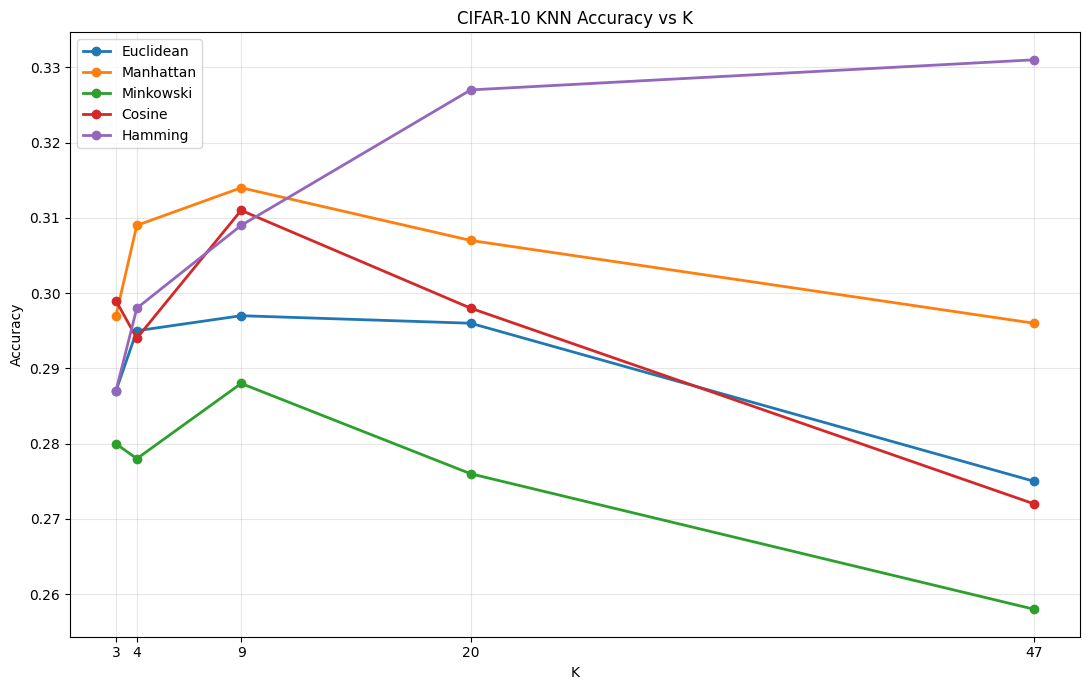

In [19]:
# ============================================================
# ACCURACY VS K
# ============================================================

plt.figure(
    figsize=(11, 7)
)

for metric in DISTANCE_METRICS:

    data = results_df[
        results_df["Distance"] == metric
    ].sort_values(
        "K"
    )

    plt.plot(
        data["K"],
        data["Accuracy"],
        marker="o",
        linewidth=2,
        label=metric
    )

plt.xlabel("K")
plt.ylabel("Accuracy")

plt.title(
    "CIFAR-10 KNN Accuracy vs K"
)

plt.xticks(K_VALUES)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()

In [20]:
# ============================================================
# BEST MODEL PREDICTIONS
# ============================================================

start = time.time()

best_predictions = knn_predict_optimized(
    X_train_small,
    y_train_small,
    X_test_small,
    k=best_k,
    metric=best_distance,
    batch_size=32,
    X_train_binary=X_train_binary,
    X_test_binary=X_test_binary,
    minkowski_p=3
)

final_accuracy = np.mean(
    best_predictions ==
    y_test_small
)

print(
    "Best model accuracy:",
    round(
        final_accuracy,
        4
    )
)

print(
    "Prediction time:",
    round(
        (time.time() - start) / 60,
        2
    ),
    "minutes"
)

Best model accuracy: 0.331
Prediction time: 0.33 minutes


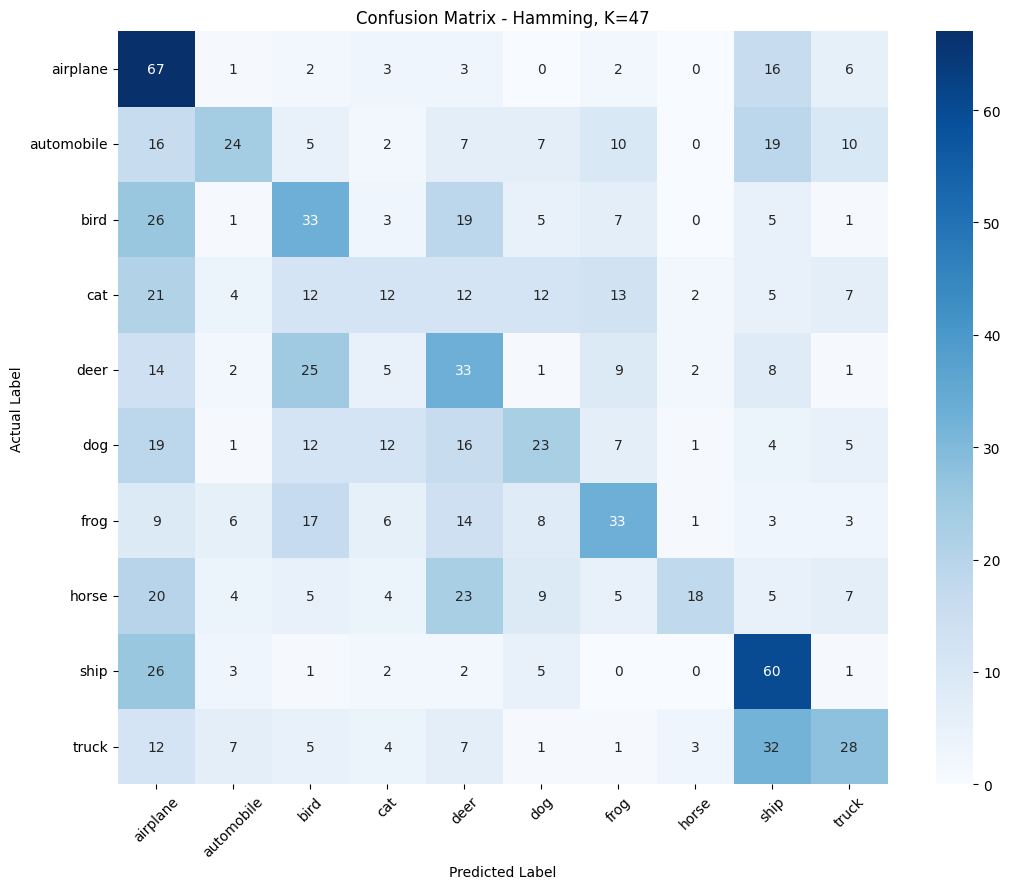

In [21]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = np.zeros(
    (10, 10),
    dtype=np.int32
)

for actual, predicted in zip(
    y_test_small,
    best_predictions
):

    cm[
        actual,
        predicted
    ] += 1


plt.figure(
    figsize=(11, 9)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.title(
    f"Confusion Matrix - "
    f"{best_distance}, K={best_k}"
)

plt.xticks(
    rotation=45
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

plt.show()

In [22]:
# ============================================================
# PRECISION AND RECALL
# ============================================================

precision = []
recall = []

for i in range(10):

    TP = cm[i, i]

    FP = (
        np.sum(cm[:, i])
        - TP
    )

    FN = (
        np.sum(cm[i, :])
        - TP
    )

    if TP + FP == 0:
        p = 0
    else:
        p = TP / (TP + FP)

    if TP + FN == 0:
        r = 0
    else:
        r = TP / (TP + FN)

    precision.append(p)
    recall.append(r)


metrics_df = pd.DataFrame({

    "Class": class_names,

    "Precision": precision,

    "Recall": recall

})

display(
    metrics_df
)

print(
    "Macro Precision:",
    round(
        np.mean(precision),
        4
    )
)

print(
    "Macro Recall:",
    round(
        np.mean(recall),
        4
    )
)

print(
    "Accuracy:",
    round(
        final_accuracy,
        4
    )
)

,Class,Precision,Recall
0,airplane,0.291304,0.67
1,automobile,0.452830,0.24
2,bird,0.282051,0.33
3,cat,0.226415,0.12
4,deer,0.242647,0.33
5,dog,0.323944,0.23
6,frog,0.379310,0.33
7,horse,0.666667,0.18
8,ship,0.382166,0.60
9,truck,0.405797,0.28


Macro Precision: 0.3653
Macro Recall: 0.331
Accuracy: 0.331


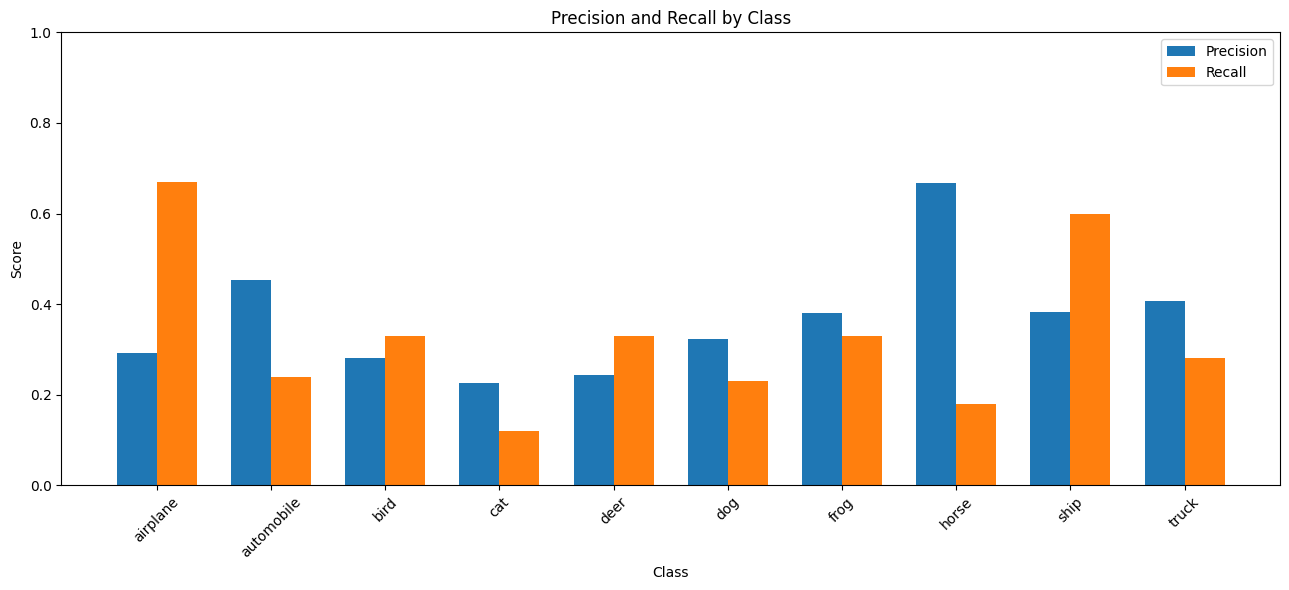

In [23]:
# ============================================================
# PRECISION AND RECALL GRAPH
# ============================================================

x = np.arange(
    len(class_names)
)

width = 0.35

plt.figure(
    figsize=(13, 6)
)

plt.bar(
    x - width / 2,
    precision,
    width,
    label="Precision"
)

plt.bar(
    x + width / 2,
    recall,
    width,
    label="Recall"
)

plt.xlabel(
    "Class"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Precision and Recall by Class"
)

plt.xticks(
    x,
    class_names,
    rotation=45
)

plt.ylim(
    0,
    1
)

plt.legend()

plt.tight_layout()

plt.show()

In [24]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("=" * 60)
print("TASK 2 FINAL SUMMARY")
print("=" * 60)

print(
    "Training images:",
    len(X_train_small)
)

print(
    "Testing images:",
    len(X_test_small)
)

print(
    "Number of experiments:",
    len(results_df)
)

print(
    "\nBest distance:",
    best_distance
)

print(
    "Best K:",
    best_k
)

print(
    "Best accuracy:",
    f"{final_accuracy:.4f}"
)

print(
    "\nMacro precision:",
    f"{np.mean(precision):.4f}"
)

print(
    "Macro recall:",
    f"{np.mean(recall):.4f}"
)

print(
    "\nResults CSV:"
)

print(
    "/content/task2_results.csv"
)

TASK 2 FINAL SUMMARY
Training images: 5000
Testing images: 1000
Number of experiments: 25

Best distance: Hamming
Best K: 47
Best accuracy: 0.3310

Macro precision: 0.3653
Macro recall: 0.3310

Results CSV:
/content/task2_results.csv
